# MiniPacman labelled MDP demo

This demo supports the tutorial section immediately after **labelling functions** and **labelled MDPs**.

The goals are:

1. inspect the MiniPacman labelling function and cost function used by MASA;
2. construct a labelled environment via `make_env`;
3. step through the environment while observing states, labels, costs, and rendered frames.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import inspect
import textwrap
import warnings
import pprint

# Make the notebook runnable when dropped into MASA-Safe-RL/tutorial/ or opened from repo root.
HERE = Path.cwd().resolve()
REPO_ROOT = None
for candidate in [HERE, *HERE.parents]:
    if (candidate / "masa").exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError(
        "Could not find a parent directory containing the `masa/` package. "
        "Open this notebook from within the MASA-Safe-RL repository, or install MASA with `pip install -e .`."
    )
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print(f"Using MASA source tree: {REPO_ROOT}")

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Importing masa.envs registers environments with MASA's registry.
import masa.envs  # noqa: F401
import masa.common.constraints  # noqa: F401
from masa.common.utils import make_env


def show_source(obj, title: str | None = None, fallback: str | None = None):
    """Display Python source for a function/class in a Markdown code block."""
    if title:
        display(Markdown(f"**{title}**"))
    try:
        src = inspect.getsource(obj)
    except Exception as exc:
        src = fallback or f"# Source unavailable for {obj!r}: {exc}"
    display(Markdown("```python\n" + textwrap.dedent(src).strip() + "\n```"))


def unwrap_chain(env, limit: int = 30):
    cur = env
    seen = []
    for _ in range(limit):
        seen.append(cur)
        nxt = getattr(cur, "env", None)
        if nxt is None or nxt is cur:
            break
        cur = nxt
    return seen


def render_frame(env):
    """Render the first usable RGB frame found while unwrapping env wrappers."""
    for cur in unwrap_chain(env):
        try:
            frame = cur.render()
            if frame is not None and not isinstance(frame, str):
                return frame
        except Exception:
            pass
    return None


def show_frames(frames, titles=None, max_cols: int = 4):
    frames = [f for f in frames if f is not None]
    if not frames:
        print("No RGB frames were captured. Try creating the env with render_mode='rgb_array'.")
        return
    n = len(frames)
    cols = min(max_cols, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.2 * rows))
    axes = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            ax.imshow(frames[i])
            if titles and i < len(titles):
                ax.set_title(str(titles[i]))
    plt.tight_layout()
    plt.show()


def nested_get(d, *keys, default=None):
    cur = d
    for key in keys:
        if not isinstance(cur, dict) or key not in cur:
            return default
        cur = cur[key]
    return cur


def compact_info(info):
    """Return a compact dict with the most useful MASA wrapper signals."""
    out = {}
    for key in ["labels", "label", "constraint", "reward", "automaton_state", "margin_penalty", "proj_penalty"]:
        if isinstance(info, dict) and key in info:
            out[key] = info[key]
    step = nested_get(info, "constraint", "step", default=None)
    episode = nested_get(info, "constraint", "episode", default=None)
    if step is not None:
        out["constraint.step"] = step
    if episode is not None:
        out["constraint.episode"] = episode
    return out

Using MASA source tree: /mnt/c/Users/alexw/OneDrive/Imperial/MASA-Safe-RL


In [2]:
from masa.envs.tabular import mini_pacman
from masa.envs.tabular.mini_pacman import MiniPacman, label_fn, cost_fn

show_source(label_fn, "MiniPacman `label_fn`")
show_source(cost_fn, "MiniPacman `cost_fn`", fallback="cost_fn = lambda labels: 1.0 if 'ghost' in labels else 0.0")

Computing successor states and probabilities ... 


100%|█████████████████████████████████████████████████████████████████████████████| 9248/9248 [00:03<00:00, 2602.95it/s]


**MiniPacman `label_fn`**

```python
def label_fn(obs):
    (agent_y, agent_x, agent_direction, ghost_y, ghost_x, ghost_direction, food) = REVERSE_STATE_MAP[obs]
    if (agent_y == FOOD[1]) and (agent_x == FOOD[0]) and (not ((agent_y, agent_x) == (ghost_y, ghost_x))) and food:
        return {"food"}
    elif (agent_y, agent_x) == (ghost_y, ghost_x):
        return {"ghost"}
    else:
        return set()
```

**MiniPacman `cost_fn`**

```python
cost_fn = lambda labels: 1.0 if "ghost" in labels else 0.0
```

The labels are semantic propositions attached to the current MDP state. In MiniPacman, the safety proposition is `ghost`, and the task proposition is `food`.

In [3]:
def decode_minipacman_state(obs: int):
    """Decode a tabular MiniPacman state id into the tuple used internally by the environment."""
    return mini_pacman.REVERSE_STATE_MAP[int(obs)]

print("Number of MiniPacman states:", mini_pacman.N_STATES)
print("Number of MiniPacman actions:", mini_pacman.N_ACTIONS)
print("Example decoded initial-like state tuple fields:")
print("(agent_y, agent_x, agent_direction, ghost_y, ghost_x, ghost_direction, food)")

Number of MiniPacman states: 9248
Number of MiniPacman actions: 5
Example decoded initial-like state tuple fields:
(agent_y, agent_x, agent_direction, ghost_y, ghost_x, ghost_direction, food)


/home/sacktock/anaconda3/envs/masa/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Initial observation: 1335
Decoded state: (1, 4, 1, 5, 3, 1, 1)
Labels: set()
Cost: 0.0
Initial info:
{'labels': set(),
 'constraint': {'type': 'CMDP',
                'step': {'cost': 0.0, 'violation': 0.0, 'cum_cost': 0.0}},
 'constraint.step': {'cost': 0.0, 'violation': 0.0, 'cum_cost': 0.0}}


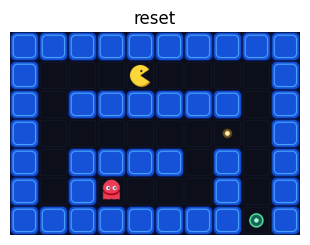

In [4]:
# `constraint='cmdp'` is enough to expose cost / violation signals through the MASA wrappers.
# We pass `constraint_kwargs={'cost_fn': cost_fn}` explicitly to avoid relying on wrapper defaults.

def make_minipacman_labelled(max_episode_steps: int = 30, seed: int = 0):
    env = make_env(
        "MiniPacman",
        "CMDP",
        max_episode_steps,
        label_fn=label_fn,
        constraint_kwargs={"cost_fn": cost_fn, "budget": 0.0},
        env_kwargs={"render_mode": "rgb_array"},
    )
    obs, info = env.reset(seed=seed)
    return env, obs, info

env, obs, info = make_minipacman_labelled(seed=7)
print("Initial observation:", obs)
print("Decoded state:", decode_minipacman_state(obs))
print("Labels:", label_fn(obs))
print("Cost:", cost_fn(label_fn(obs)))
print("Initial info:")
pprint.pp(compact_info(info))
frame = render_frame(env)
show_frames([frame], ["reset"])

{'t': 1,
 'action': 0,
 'obs': 1607,
 'decoded': (1, 5, 1, 5, 3, 1, 1),
 'labels': [],
 'cost': 0.0,
 'reward': 0.0,
 'terminated': False,
 'truncated': False,
 'info': {'labels': set(),
          'constraint': {'type': 'CMDP', 'step': {'cost': 0.0, 'violation': 0.0, 'cum_cost': 0.0}},
          'constraint.step': {'cost': 0.0, 'violation': 0.0, 'cum_cost': 0.0}}}
------------------------------------------------------------------------------------------------------------------------
{'t': 2,
 'action': 1,
 'obs': 1879,
 'decoded': (1, 6, 1, 5, 3, 1, 1),
 'labels': [],
 'cost': 0.0,
 'reward': 0.0,
 'terminated': False,
 'truncated': False,
 'info': {'labels': set(),
          'constraint': {'type': 'CMDP', 'step': {'cost': 0.0, 'violation': 0.0, 'cum_cost': 0.0}},
          'constraint.step': {'cost': 0.0, 'violation': 0.0, 'cum_cost': 0.0}}}
------------------------------------------------------------------------------------------------------------------------
{'t': 3,
 'action': 1,
 

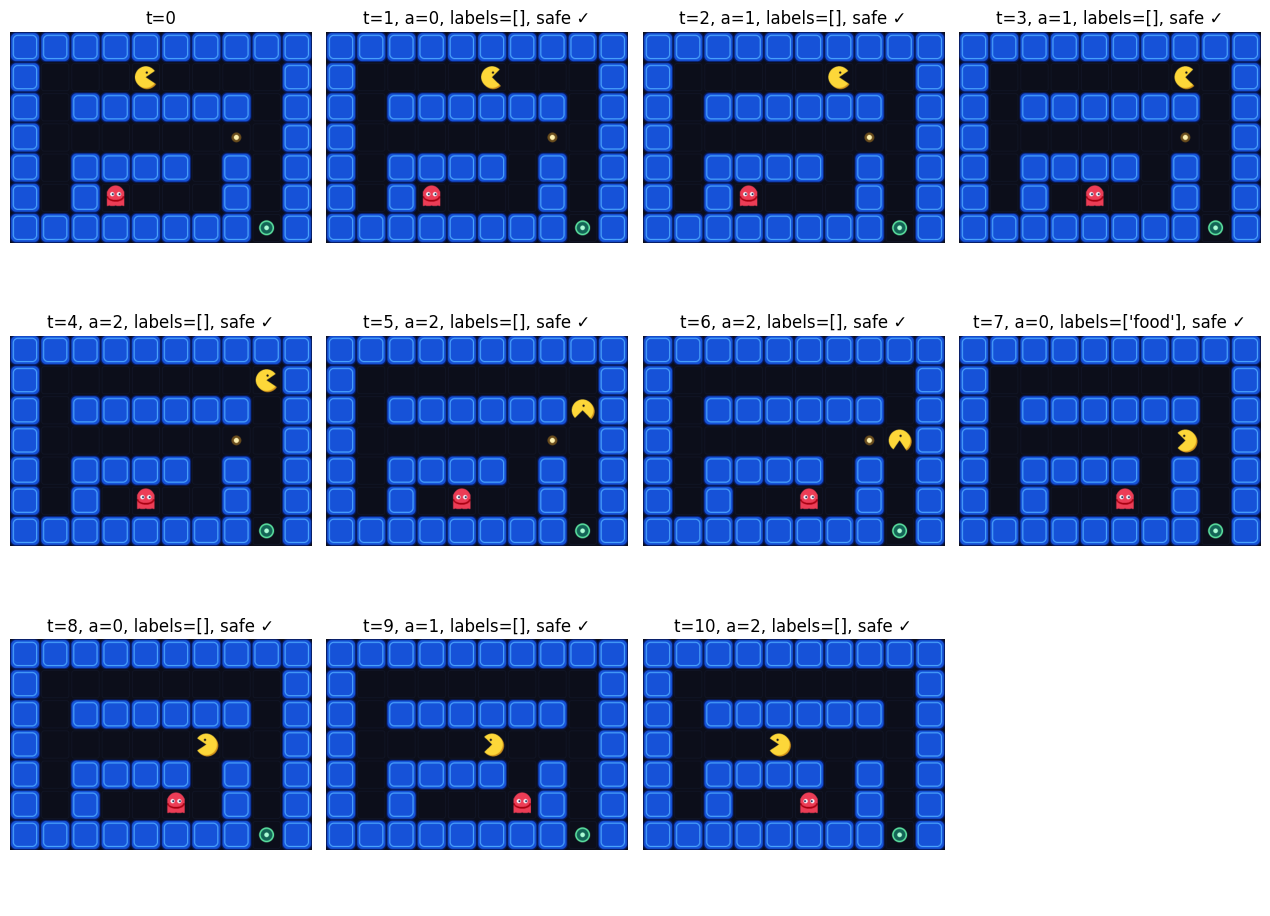

In [6]:
# A short scripted rollout. Change the seed or action script if you want to show a ghost collision or food collection.
# The action meanings are environment-specific; for the tutorial, the important thing is the label stream.

action_script = [0, 1, 1, 2, 2, 2, 0, 0, 1, 2]
frames, titles, rows = [], [], []

obs, info = env.reset(seed=11)
frames.append(render_frame(env))
titles.append("t=0")

for t, action in enumerate(action_script, start=1):
    next_obs, reward, terminated, truncated, info = env.step(action)
    labels = label_fn(next_obs)
    cost = cost_fn(labels)
    row = {
        "t": t,
        "action": action,
        "obs": int(next_obs),
        "decoded": decode_minipacman_state(next_obs),
        "labels": sorted(labels),
        "cost": float(cost),
        "reward": float(reward),
        "terminated": bool(terminated),
        "truncated": bool(truncated),
        "info": compact_info(info),
    }
    rows.append(row)
    frames.append(render_frame(env))
    titles.append(f"t={t}, a={action}, labels={sorted(labels)}, safe {'✓' if not compact_info(info)['constraint.step']['violation'] else 'X'}")
    obs = next_obs
    if terminated or truncated:
        break

for row in rows:
    pprint.pp(row, width=140)
    print("-" * 120)

show_frames(frames, titles)

**Talking point.** The labelled MDP does not change the underlying dynamics; it enriches observations with propositions that can be consumed by constraints, monitors, and shields.